In [1]:
import numpy as np
import sklearn 
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
%pip install nltk


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
animeData = pd.read_csv('./animes.csv')
print(animeData)

         uid                                        title  \
0      28891                      Haikyuu!! Second Season   
1      23273                      Shigatsu wa Kimi no Uso   
2      34599                                Made in Abyss   
3       5114             Fullmetal Alchemist: Brotherhood   
4      31758             Kizumonogatari III: Reiketsu-hen   
...      ...                                          ...   
19306  32979                                Flip Flappers   
19307    123                                Fushigi Yuugi   
19308   1281                             Gakkou no Kaidan   
19309    450  InuYasha Movie 2: Kagami no Naka no Mugenjo   
19310     87     Mobile Suit Gundam: Char's Counterattack   

                                                synopsis  \
0      Following their participation at the Inter-Hig...   
1      Music accompanies the path of the human metron...   
2      The Abyss—a gaping chasm stretching down into ...   
3      "In order for someth

In [3]:
import re

uniqueGenres = []
cleanedGenres = []
for genre in animeData['genre']:
    currentGenre = genre.split(',')
    currentGenreCleaned = re.sub(r'[\[\]\(\)\"\,]', '', genre)  # Remove non-alphanumeric characters
    # print(currentGenreCleaned)
    cleanedGenres.append(currentGenreCleaned)
    finalGenreSplit = currentGenreCleaned.split("' '")  # Split into individual genres
    for individualGenre in finalGenreSplit:
        individualGenre = re.sub(r'[\']', '', individualGenre)
        if individualGenre not in uniqueGenres and individualGenre != '':
            uniqueGenres.append(individualGenre)

print (uniqueGenres)



['Comedy', 'Sports', 'Drama', 'School', 'Shounen', 'Music', 'Romance', 'Sci-Fi', 'Adventure', 'Mystery', 'Fantasy', 'Action', 'Military', 'Magic', 'Supernatural', 'Vampire', 'Slice of Life', 'Demons', 'Historical', 'Super Power', 'Mecha', 'Parody', 'Samurai', 'Seinen', 'Police', 'Psychological', 'Josei', 'Space', 'Kids', 'Shoujo Ai', 'Ecchi', 'Shoujo', 'Horror', 'Shounen Ai', 'Cars', 'Martial Arts', 'Game', 'Thriller', 'Dementia', 'Harem', 'Hentai', 'Yaoi', 'Yuri']


In [4]:
cleanedGenres
# animeData['text'] = animeData['title'] + " " + animeData['synopsis'] # Combine title and synopsis into a single text field
animeData['text'] = animeData['synopsis']   
print(cleanedGenres[:3])
print(animeData['text'][:3])

["'Comedy' 'Sports' 'Drama' 'School' 'Shounen'", "'Drama' 'Music' 'Romance' 'School' 'Shounen'", "'Sci-Fi' 'Adventure' 'Mystery' 'Drama' 'Fantasy'"]
0    Following their participation at the Inter-Hig...
1    Music accompanies the path of the human metron...
2    The Abyss—a gaping chasm stretching down into ...
Name: text, dtype: object


In [5]:
from email.mime import text
import re
import nltk
from nltk.stem import WordNetLemmatizer

# Download required resources for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    text = str(text)  # Ensure the input is a string
    text = re.sub(r'[^a-z0-9\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text)         # remove extra spaces
    text = text.lower()                      # remove all capitals

    # Split the cleaned text into words and lemmatize each word (get root form)
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    text = " ".join(lemmatized_words)
    return text

animeData['text'] = animeData['text'].apply(clean_text)
print(animeData['text'][:3])

[nltk_data] Downloading package wordnet to /home/zayne/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/zayne/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


0    ollowing their participation at the nterigh th...
1    usic accompanies the path of the human metrono...
2    he byssa gaping chasm stretching down into the...
Name: text, dtype: object


In [6]:
from sklearn.preprocessing import MultiLabelBinarizer

# Convert string to list
formattedGenres = []
for genre in animeData['genre']:
    currentGenre = genre.split(',')
    currentGenreCleaned = re.sub(r'[\[\]\(\)\"\,]', '', genre)  # Remove non-alphanumeric characters
    finalGenreSplit = currentGenreCleaned.split("' '")  # Split into individual genres
    tempList = []
    for individualGenre in finalGenreSplit: 
        if individualGenre != '':
            individualGenre = re.sub(r'[\']', '', individualGenre)
            tempList.append(individualGenre.strip())
    formattedGenres.append(tempList)

print(formattedGenres[:3])
print(animeData['genre'][:3])
print(animeData['title'][:3])

# for i, genres in enumerate(formattedGenres):
#     animeData['genre_list'][i] = genres
        
print(formattedGenres[0][0])

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(formattedGenres)

print(mlb.classes_)  # All genre labels

[['Comedy', 'Sports', 'Drama', 'School', 'Shounen'], ['Drama', 'Music', 'Romance', 'School', 'Shounen'], ['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'Fantasy']]
0    ['Comedy', 'Sports', 'Drama', 'School', 'Shoun...
1    ['Drama', 'Music', 'Romance', 'School', 'Shoun...
2    ['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...
Name: genre, dtype: object
0    Haikyuu!! Second Season
1    Shigatsu wa Kimi no Uso
2              Made in Abyss
Name: title, dtype: object
Comedy
['Action' 'Adventure' 'Cars' 'Comedy' 'Dementia' 'Demons' 'Drama' 'Ecchi'
 'Fantasy' 'Game' 'Harem' 'Hentai' 'Historical' 'Horror' 'Josei' 'Kids'
 'Magic' 'Martial Arts' 'Mecha' 'Military' 'Music' 'Mystery' 'Parody'
 'Police' 'Psychological' 'Romance' 'Samurai' 'School' 'Sci-Fi' 'Seinen'
 'Shoujo' 'Shoujo Ai' 'Shounen' 'Shounen Ai' 'Slice of Life' 'Space'
 'Sports' 'Super Power' 'Supernatural' 'Thriller' 'Vampire' 'Yaoi' 'Yuri']


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fill missing values in 'text' column with empty strings for processing (Might remove them from the list of anime to train on later)
# animeData['text'] = animeData['text'].fillna('')

# Create TF-IDF features from the 'text' column as vectorized input for the model (Limited to top 5000 words, removing English stop words)
tfidf = TfidfVectorizer(
    max_features=5000, 
    stop_words='english',
    ngram_range=(1,2)  # unigrams + bigrams
) # 

X = tfidf.fit_transform(animeData['text'])

In [8]:
from sklearn.model_selection import train_test_split

# First split: train + temp
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X, y, animeData.index, test_size=0.3, random_state=67
)

# Second split: validation + test
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.5, random_state=69
)

print(X_train.shape, X_val.shape, X_test.shape)

(13517, 5000) (2897, 5000) (2897, 5000)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

model = OneVsRestClassifier(LogisticRegression(max_iter=2000))
model.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=2000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [10]:
from sklearn.metrics import classification_report, f1_score

y_val_probs = model.predict_proba(X_val)
thresholds = [0.2, 0.3, 0.4, 0.5]
best_f1 = 0
best_threshold = 0.5

# Tune threshold on validation set
for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred, average='micro')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold, "F1-micro on validation:", best_f1)

# Predict on test set using best threshold 
y_test_probs = model.predict_proba(X_test)
y_test_pred = (y_test_probs >= best_threshold).astype(int)

# Print classification report
print(classification_report(y_test, y_test_pred, target_names=mlb.classes_))


# Convert to readable genre names
true_labels = mlb.inverse_transform(y_test)
pred_labels = mlb.inverse_transform(y_test_pred)

# Compare first 100 samples
for i in range(100):
    print("TEXT:", animeData.loc[idx_test[i], 'title'])
    print("ACTUAL:", true_labels[i])
    print("PREDICTED:", pred_labels[i])
    print("-----")

Best threshold: 0.2 F1-micro on validation: 0.5429849262878913
               precision    recall  f1-score   support

       Action       0.47      0.81      0.59       630
    Adventure       0.45      0.71      0.55       499
         Cars       1.00      0.12      0.22        16
       Comedy       0.45      0.93      0.61       983
     Dementia       0.58      0.25      0.35        71
       Demons       0.72      0.22      0.33        83
        Drama       0.39      0.62      0.48       454
        Ecchi       0.28      0.09      0.13       103
      Fantasy       0.41      0.71      0.52       533
         Game       0.60      0.14      0.23        65
        Harem       0.50      0.02      0.03        61
       Hentai       0.62      0.90      0.73       384
   Historical       0.59      0.33      0.43       171
       Horror       0.71      0.06      0.11        82
        Josei       1.00      0.12      0.22         8
         Kids       0.60      0.66      0.63       388
 

/home/zayne/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zayne/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zayne/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zayne/.local/li

In [11]:
# Get top words for each genre
for i, genre in enumerate(mlb.classes_):
    top10 = np.argsort(model.estimators_[i].coef_[0])   # Get sorted indices of features based on coefficients for this genre (Lowest to highest)
    top10 = top10[-10:]                                 # Take the top 10 indices (highest coefficients)
    print(f"\nTop words for {genre}:")
    print([tfidf.get_feature_names_out()[j] for j in top10])


Top words for Action:
['power', 'warrior', 'unter', 'fighting', 'lade', 'assassin', 'arc', 'fight', 'upin', 'battle']

Top words for Adventure:
['mysterious', 'world', 'quest', 'travel', 'igimon', 'onan', 'okmon', 'upin', 'journey', 'adventure']

Top words for Cars:
['driver', 'street', 'akumi', 'season', 'driving', 'racer', 'ayo', 'race', 'racing', 'car']

Top words for Comedy:
['npanman', 'comedic', 'odd', 'parody', 'special', 'uffy', 'oraemon', 'gag', 'upin', 'comedy']

Top words for Dementia:
['eiichi', 'short', 'surreal', 'urukawa', 'image', 'fficial', 'animation', 'ilm', 'anaami', 'film']

Top words for Demons:
['sagi', 'yo', 'evil', 'oukai', 'human', 'monster', 'nuyasha', 'atsume', 'youkai', 'demon']

Top words for Drama:
['aired special', 'amato', 'begin', 'uuki', 'life', 'year', 'relationship', 'educational film', 'atsume', 'educational']

Top words for Ecchi:
['bundled', 'lurays', 'included', 'cademy', 'io', 'ouma', 'special', 'ueens', 'beautiful', 'girl']

Top words for Fan

/home/zayne/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/tmp/ipykernel_658894/2055022006.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Score', y='Genre', data=df_metrics, palette='viridis')


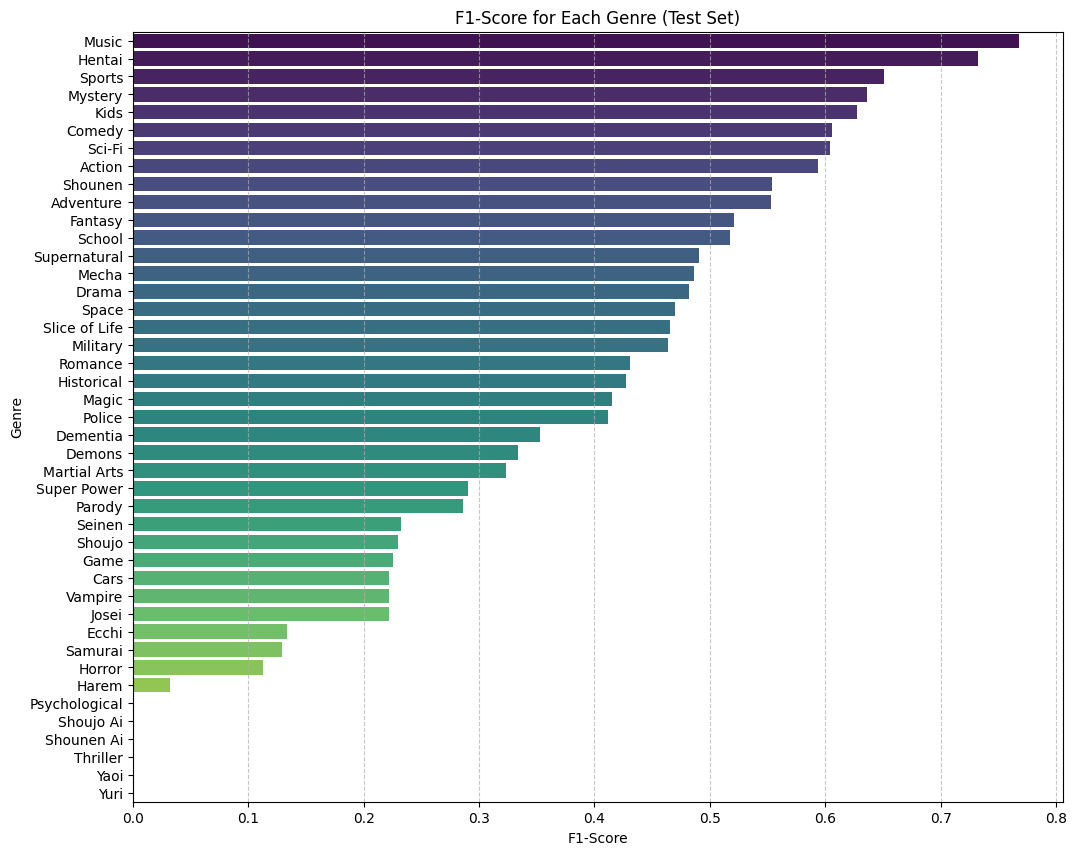

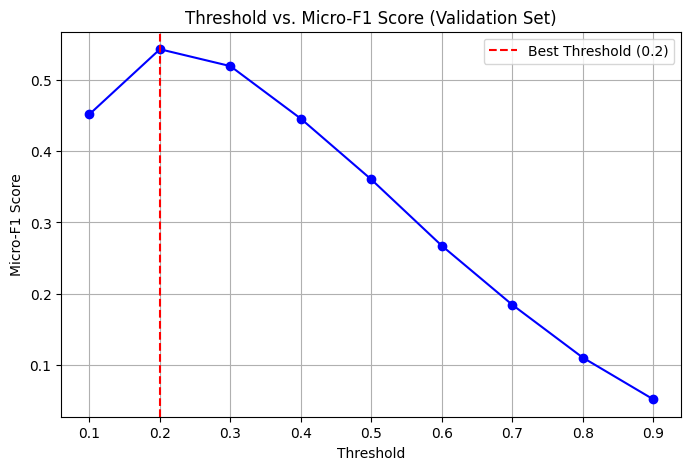

/home/zayne/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


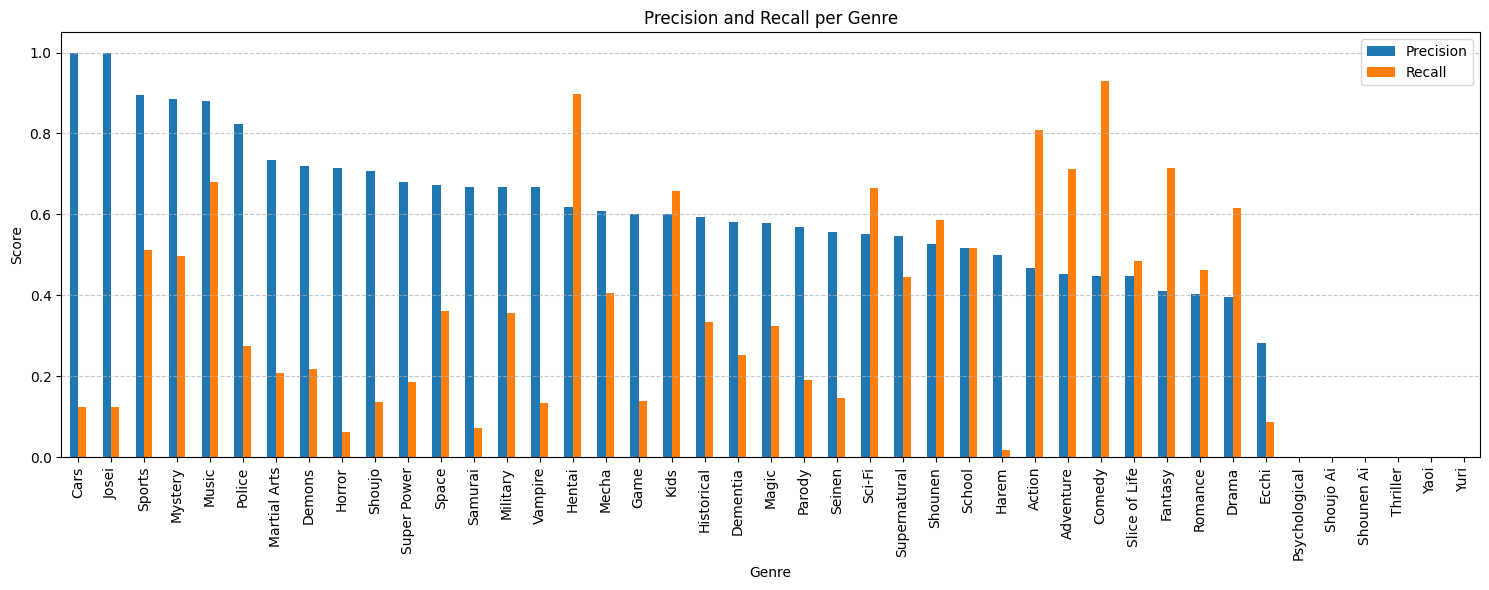

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Plot F1-Score per Genre
# Get metrics for each genre
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average=None)
genre_names = mlb.classes_

# Create a DataFrame for plotting
df_metrics = pd.DataFrame({
    'Genre': genre_names,
    'F1-Score': f1
}).sort_values(by='F1-Score', ascending=False)

# Create the plot (1)
plt.figure(figsize=(12, 10))
sns.barplot(x='F1-Score', y='Genre', data=df_metrics, palette='viridis')
plt.title('F1-Score for Each Genre (Test Set)')
plt.xlabel('F1-Score')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Plot Threshold Tuning
score_history = []
test_thresholds = np.linspace(0.1, 0.9, 9) 

for t in test_thresholds:
    y_val_pred_t = (y_val_probs >= t).astype(int)
    score_history.append(f1_score(y_val, y_val_pred_t, average='micro'))


# Create the plot (2)
plt.figure(figsize=(8, 5))
plt.plot(test_thresholds, score_history, marker='o', linestyle='-', color='b')
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Best Threshold ({best_threshold})')
plt.title('Threshold vs. Micro-F1 Score (Validation Set)')
plt.xlabel('Threshold')
plt.ylabel('Micro-F1 Score')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Precision and Recall per Genre
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_test_pred, average=None)

# Organize into a DataFrame
metrics_df = pd.DataFrame({
    'Genre': mlb.classes_,
    'Precision': precision,
    'Recall': recall
}).set_index('Genre')

# Create the plot (3)
metrics_df.sort_values(by='Precision', ascending=False).plot(kind='bar', figsize=(15, 6))

plt.title('Precision and Recall per Genre')
plt.ylabel('Score')
plt.xlabel('Genre')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()